# Q1. ax, Autograd and Neural Networks (40 points + 14 Bonus points)

## (a) Univariate Function Gradient (5 points)

In [2]:
import jax.numpy as jnp
from jax import grad, jit, vmap
from jax import random
import numpy as np

# Q1a.  Example for taking the derivative of a simple function

def fun(x):
    return jnp.cos(x**3 - 2*x**2 + 5)

def manual_grad(x):
    # Implement the derivative w.r.t. x
    # ==================YOUR CODE HERE =================
    gradient=-(3*x**2-4*x)*jnp.sin(x**3-2*x**2+5)
    # ==================================================
    return gradient

grad_fun = grad(fun)

x = 3.5

print("Gradient:", grad_fun(x),  manual_grad(x))


Gradient: 22.353619 22.353619


## (b) Multivariate Function Gradient (5 points)

In [3]:
# Now let's do it for a multivariate case

#Q1b.  Please complete the manual grad.


def cubic_l2_norm(x):
    return jnp.linalg.norm(x)**3

# Now complete the following line
grad_fun = grad(cubic_l2_norm)


x = jnp.array([5.0,0.3,2])

def manual_grad(x):
    # Manually implement the gradient w.r.t. x
    # ==================YOUR CODE HERE =================
    gradient = 3*jnp.linalg.norm(x)*x
    # ==================================================
    return gradient

print("Gradient:", grad_fun(x),  manual_grad(x))



Gradient: [80.902725  4.854164 32.36109 ] [80.90272   4.854163 32.361088]


### Implement a function that computes the Hessian matrix for the given function (2 Bonus points)

In [6]:
# Code for computing Hessian matrix
from jax import jacfwd
def hessian(fun, x):
  return jacfwd(grad(fun))(x)

## (c) Soft-Max Regression and Neural Networks (15 points)

In [7]:

# Q1c. Neural Network from Scratch
# Example implementation of simple soft-max regression with square loss
#[Nothing to implement in this block]

# define soft argmax
def soft_argmax(x):
    y = jnp.exp(x)
    return y/jnp.sum(y)

# Specify the how to caculate the

def predict(params, inputs):
    W = params[0]
    b = params[1]
    scores = jnp.dot( W, inputs) + b
    outputs = soft_argmax(scores)
    return outputs

def loss_fun(params, inputs, targets):
    preds = predict(params, inputs)
    # You can use cross-entropy loss instead
    return jnp.sum((preds - targets)**2)

grad_fun = grad(loss_fun)  # gradient evaluation function

# Lets' cook up some input for this
W = np.random.randn(3,4)
b = np.random.randn(3,1)
inputs = np.random.randn(4,1)
targets = np.array([1,0,0])
params=[W,b]



In [8]:
# Example usage of above functions
# [Nothing to implement in this block]

# How to Generate a prediction for this inputs
print(predict(params, inputs))

# How to Compute the gradient from this imput
print(grad_fun(params, inputs,targets))

# How to implement an SGD udpate
# Take a minibatch of data X,y
def sgd_update(params,X,y):
    lr = 0.01
    gradient = grad_fun(params,X,y)
    for param, g in zip(params,gradients):
        param -= lr*g


[[0.00163962]
 [0.26102746]
 [0.737333  ]]
[Array([[-4.6323608e-03, -1.3241624e-04, -3.9420690e-04,  7.0162904e-03],
       [-4.2396045e-01, -1.2118929e-02, -3.6078397e-02,  6.4214122e-01],
       [ 4.2859265e-01,  1.2251341e-02,  3.6472589e-02, -6.4915729e-01]],      dtype=float32), Array([[-0.00600257],
       [-0.5493644 ],
       [ 0.55536675]], dtype=float32)]


**Now you are expected to implement a two-layer neural network from scratch by modifying the above code for soft-max regression.**

**Very Important the only function you need to modify is** `predict_nn`

In [9]:
# Q1c.  continues

#  You may use jnp.tanh to implement a hyperbolic tangent activation fuonction.
#

def predict_nn(params, inputs):

    W1 = params[0]
    b1 = params[1]
    W2 = params[2]
    b2 = params[3]

    # ==================YOUR CODE HERE =================

    # implement the score function of a two layer neural networks.

    # ==================================================
    scores=jnp.dot(W2,jnp.tanh(jnp.dot(W1,inputs)+b1))+b2
    outputs = soft_argmax(scores)
    return outputs


def loss_fun_nn(params, inputs, targets):
    preds = predict_nn(params, inputs)
    # You can use logistic loss instead
    return jnp.sum((preds - targets)**2)

grad_fun_nn = grad(loss_fun_nn)  # gradient evaluation function

## (d) Neural Network Parameters and Gradient (15 points)
Now let's say the neural network is supposed to classify

In [10]:
# Q1d Lets' cook up some input:

inputs = np.random.randn(64,1)
targets = np.array([1,0,0])

# What could be a valid shape of the following parameters?  Replace the question marks with valid numbers

# ==================YOUR CODE HERE =================

W1 = np.random.randn(20,64)
b1 = np.random.randn(20,1)
W2 = np.random.randn(3,20)
b2 = np.random.randn(3,1)

 # ==================================================

# W1 = np.random.randn(6,2)
# b1 = np.random.randn(6,1)
# W2 = np.random.randn(3,6)
# b2 = np.random.randn(3,1)
params=[W1,b1,W2,b2]



In [ ]:
# Generate a prediction for this inputs
predict_nn(params, inputs)

# Compute the gradient from this imput
grad_fun_nn(params, inputs,targets)

[Array([[ 0.00309208,  0.02634501],
        [ 0.05308639,  0.45230433],
        [-0.09310891, -0.79330254],
        [-0.03095572, -0.2637476 ],
        [ 0.04543963,  0.38715276],
        [ 0.01311291,  0.11172401]], dtype=float32),
 Array([[-0.02114253],
        [-0.36298558],
        [ 0.6366452 ],
        [ 0.21166407],
        [-0.31069982],
        [-0.08966132]], dtype=float32),
 Array([[ 0.17251822, -0.11501967, -0.12219113, -0.09222406,  0.05304084,
          0.19924021],
        [-0.470095  ,  0.31341717,  0.33295867,  0.25130138, -0.14453101,
         -0.54290974],
        [ 0.2975768 , -0.19839753, -0.21076758, -0.15907736,  0.09149019,
          0.3436696 ]], dtype=float32),
 Array([[-0.22494145],
        [ 0.61294305],
        [-0.38800168]], dtype=float32)]

(e) Digit Classification from Scratch

1. Three layers

2. The params list contains pairs of weight matrices (W) and bias vectors (b) for each of the 3 layers. Based on the random_layer_params function returning (n, m) for weights and (n,) for biases, the shapes are:
Layer 1: Weight: (512, 784), Bias: (512,)
Layer 2: Weight: (512, 512), Bias: (512,)
Layer 3: Weight: (10, 512), Bias: (10,)

3. ReLU(Rectified Linear Unit) activation function is used for the hidden layers, as defined by def relu(x): return jnp.maximum(0,xx)
4. Input space: 784-dimensional vectors.Lable space: 10 dimensions.  
5. Predict function outputs the log-probabilities (log-softmax) of the 10 classes.

6. Traning set accuracy: 98.02% Test set accuracy: 97.13%
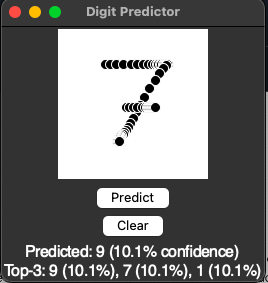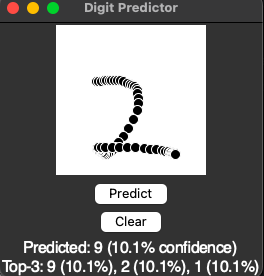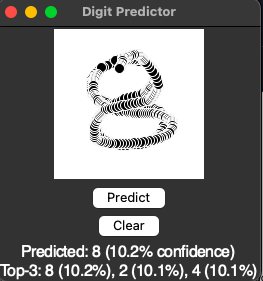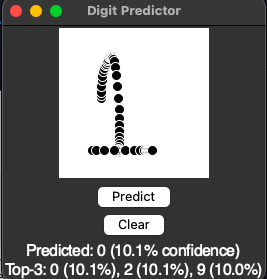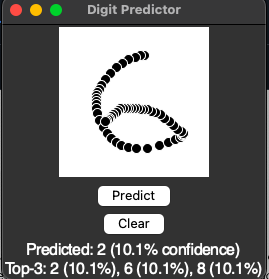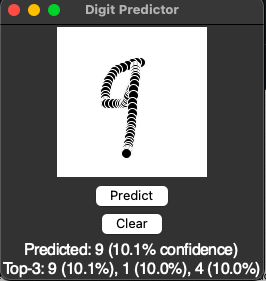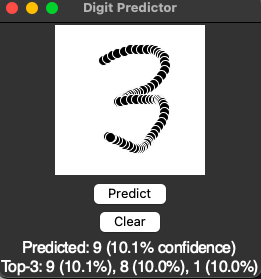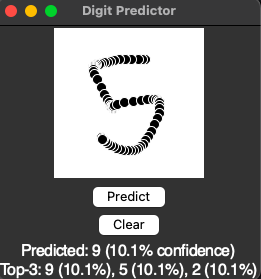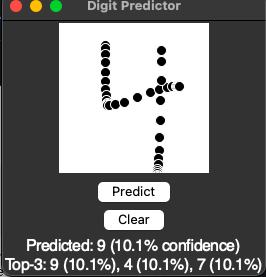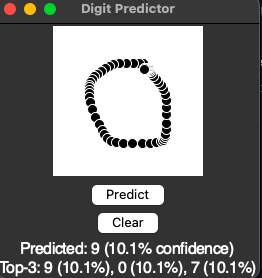

The classification accuracy on my hand-drawn data was notably lower 30% accuracy than the test set accuracy of approximately 97.13%. This discrepancy is primarily due to a distribution shift between the standardized MNIST training data and the raw inputs from the GUI. While the MNIST images are normalized and centered by their center of mass, mouse-drawn digits vary significantly in position and stroke thickness. Because the model uses a fully-connected architecture with layer sizes of [784, 512, 512, 10] and ReLU activations, it lacks the spatial invariance required to handle these deviations. Interestingly, further analysis of the model's log-probability outputs indicates that even when the primary prediction is incorrect, the "second guess" (the second-highest probability) often identifies the correct digit, suggesting the model has learned the essential features but is hindered by the input's centering. To improve performance, I could implement data augmentation or add a preprocessing step to center and scale the GUI drawings to the 28 x 28 MNIST standard.

#  Q2.  Implement the Lloyd's algorithm for k-means (30 points)

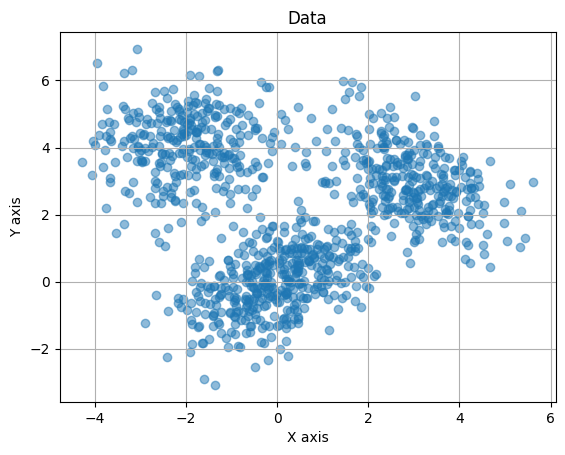

In [1]:
# First generate and visualize the input data


import numpy as np
import matplotlib.pyplot as plt

# Parameters for the mixture components
means = [np.array([0, 0]), np.array([3, 3]), np.array([-2, 4])]
covs = [np.array([[1, 0.5], [0.5, 1]]), np.array([[1, -0.5], [-0.5, 1]]), np.array([[1, 0], [0, 1]])]
weights = [0.4, 0.3, 0.3]  # Must sum to 1
num_samples = 1000

# Generate samples
samples = []
for mean, cov, weight in zip(means, covs, weights):
    num_component_samples = int(weight * num_samples)
    component_samples = np.random.multivariate_normal(mean, cov, num_component_samples)
    samples.append(component_samples)

# Combine samples from all components
data = np.vstack(samples)

# Plot
plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.title('Data')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.grid(True)
plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_centroids(data, k):
    # Randomly select k data points from the dataset as centroids
    indices = np.random.choice(data.shape[0], k, replace=False)
    return data[indices]

def assign_clusters(data, centroids):
    # Return a vector of integers in {0,1,2,3,...,k-1} to indicate the cluster assignments of data points
    # the vector should be of length as long as the data size

    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    clusters = np.argmin(distances, axis=1)

    return clusters

def update_centroids(data, clusters, k):
    # update the centroids
    new_centroids = []

    for i in range(k):
        cluster_points = data[clusters == i]

        # If a cluster becomes empty, reinitialize its centroid randomly
        if len(cluster_points) == 0:
            new_centroids.append(data[np.random.choice(data.shape[0])])
        else:
            new_centroids.append(cluster_points.mean(axis=0))

    return np.array(new_centroids)

def kmeans(data, k, max_iters=100,tol=1e-6):
    centroids = initialize_centroids(data, k)
    # Write a for loop to implement the kmeans algorithm
    for _ in range(max_iters):
        clusters = assign_clusters(data, centroids)
        new_centroids = update_centroids(data, clusters, k)

        # Stop if centroids do not change much
        if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < tol):
            centroids = new_centroids
            break

        centroids = new_centroids

    return centroids, clusters


Centroids: [[ 2.91355536  2.94136931]
 [-0.11160335 -0.03612667]
 [-1.96242102  4.11605298]]


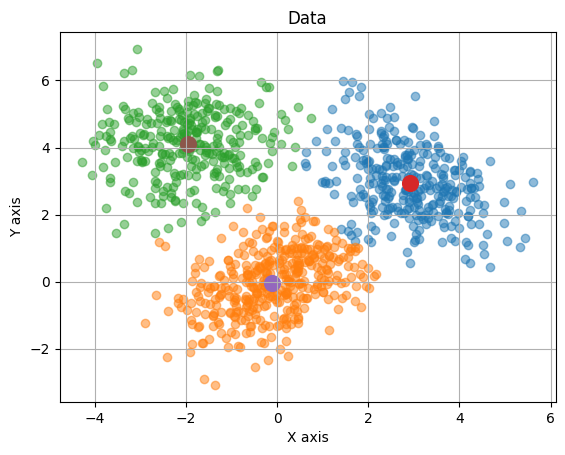

In [8]:
# If your implementation is valid, then the following should generate the clustering in colors.

k=3
centroids, clusters = kmeans(data,k)
print("Centroids:", centroids)
# Plot
colors =  plt.get_cmap("tab10")

for i in range(k):
    plt.scatter(data[clusters==i, 0], data[clusters==i, 1], color=colors(i), alpha=0.5)
for i in range(k):
    plt.scatter(centroids[i,0],centroids[i,1],marker='o',s=128,color=colors(i+k))
plt.title('Data')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.grid(True)
plt.show()


## Next, let's do clustering of a real data set "Olivetti faces".    The same function you implemented above should work on this dataset directly without changes.



1. Do you get the same results each time you run k-means?  Why?

No, you do not necessarily get the same results each time you run k-means. This is because the algorithm starts by choosing random initial centroids, and different initial choices can lead the algorithm to different final cluster assignments and centroid locations. Since Lloydâ€™s algorithm only guarantees convergence to a local optimum, the final result depends on the starting point. If a fixed random seed is used, then the results become reproducible.

2. Describe what you see when you adjust k.  You may reorganize the subplot layouts to see clearly.

When k is small, each cluster contains a wider variety of points or faces, so the centroids look more averaged and less specific. As k increases, the clusters become more specialized, and the centroid faces begin to capture more distinct facial structure, pose, or lighting patterns. In the synthetic 2D dataset, increasing k splits the data into more groups, sometimes separating natural clusters and sometimes over-partitioning them. In the Olivetti faces dataset, larger k generally produces centroids that look sharper and more representative of smaller subgroups of faces.


3. What are the prominent differences you can see between the raw images and the "centroid faces"?

The raw images are individual human faces with clear personal details, sharper features, and natural variation in expression, lighting, and pose. The centroid faces are averages of many images in the same cluster, so they tend to look blurrier and smoother. Fine details such as wrinkles, hair texture, and sharp edges are reduced, while the overall shared structure of the face is preserved. As a result, centroid faces capture the common pattern of a cluster rather than the appearance of a single real person.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


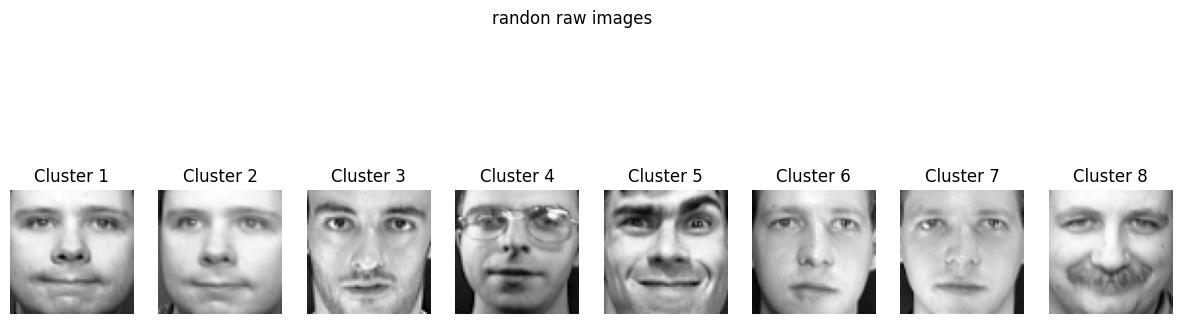

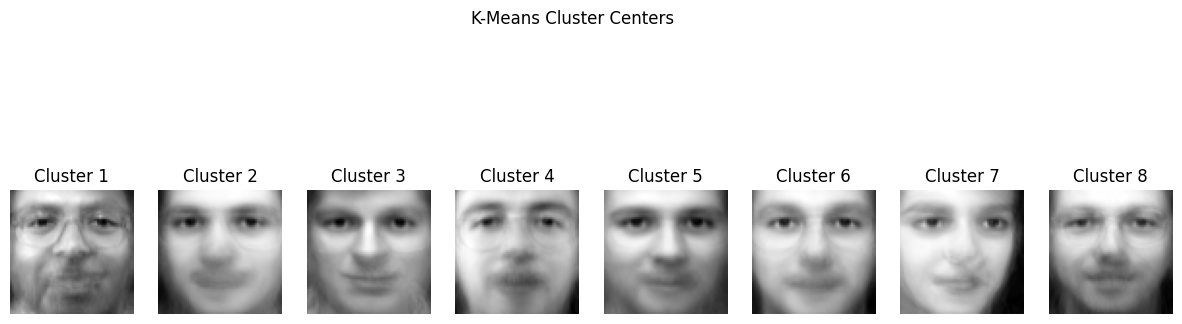

In [9]:
from sklearn.datasets import fetch_olivetti_faces

# We'll fetch the Olivetti faces dataset
data = fetch_olivetti_faces().data

k = 8  # number of clusters

random_imgs = initialize_centroids(data, k)

# Visualize the cluster centers as images
plt.figure(figsize=(15, 5))
for i, centroid in enumerate(random_imgs ):
    plt.subplot(1, k, i + 1)
    plt.imshow(centroid.reshape(64, 64), cmap='gray')
    plt.title(f'Cluster {i+1}')
    plt.axis('off')
plt.suptitle('randon raw images')
plt.show()

# Apply K-Means Clustering
centroids, _ = kmeans(data, k)

# Visualize the cluster centers as images
plt.figure(figsize=(15, 5))
for i, centroid in enumerate(centroids):
    plt.subplot(1, k, i + 1)
    plt.imshow(centroid.reshape(64, 64), cmap='gray')
    plt.title(f'Cluster {i+1}')
    plt.axis('off')
plt.suptitle('K-Means Cluster Centers')
plt.show()



# Q3. PCA for Dimension Reduction (30 points)
In this problem, we will implement the Principal Component analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces


def pca(data, num_components):

    # ==================YOUR CODE HERE =================

    # (1) estimate and subtract the mean
    mean = np.mean(data, axis=0)
    centered_data = data - mean

    # (2) construct the covariance matrix
    covariance_matrix = np.cov(centered_data, rowvar=False)

    # (3) find eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # sort eigenvalues/eigenvectors in descending order
    sorted_idx = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_idx]
    sorted_eigenvectors = eigenvectors[:, sorted_idx]

    # keep the top k
    top_eigenvalues = sorted_eigenvalues[:num_components]
    top_eigenvectors = sorted_eigenvectors[:, :num_components]

    # ==================================================

    return top_eigenvalues, top_eigenvectors

# The following code help you to visualize your eigenvectors

data = fetch_olivetti_faces().data

num_components = 20  # Number of principal components
eigenvalues, principal_components = pca(data, num_components)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


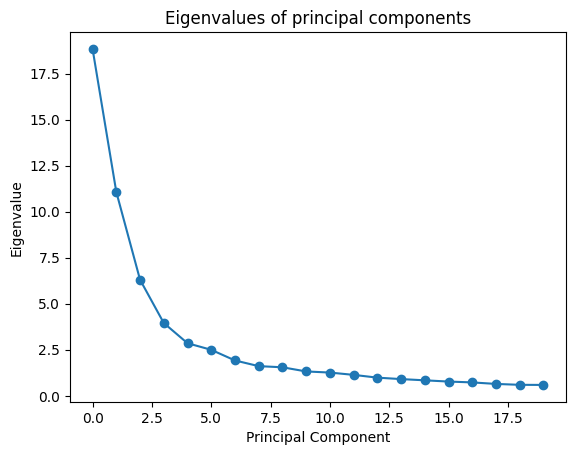

In [4]:
plt.plot(eigenvalues, 'o-')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of principal components')
plt.show()

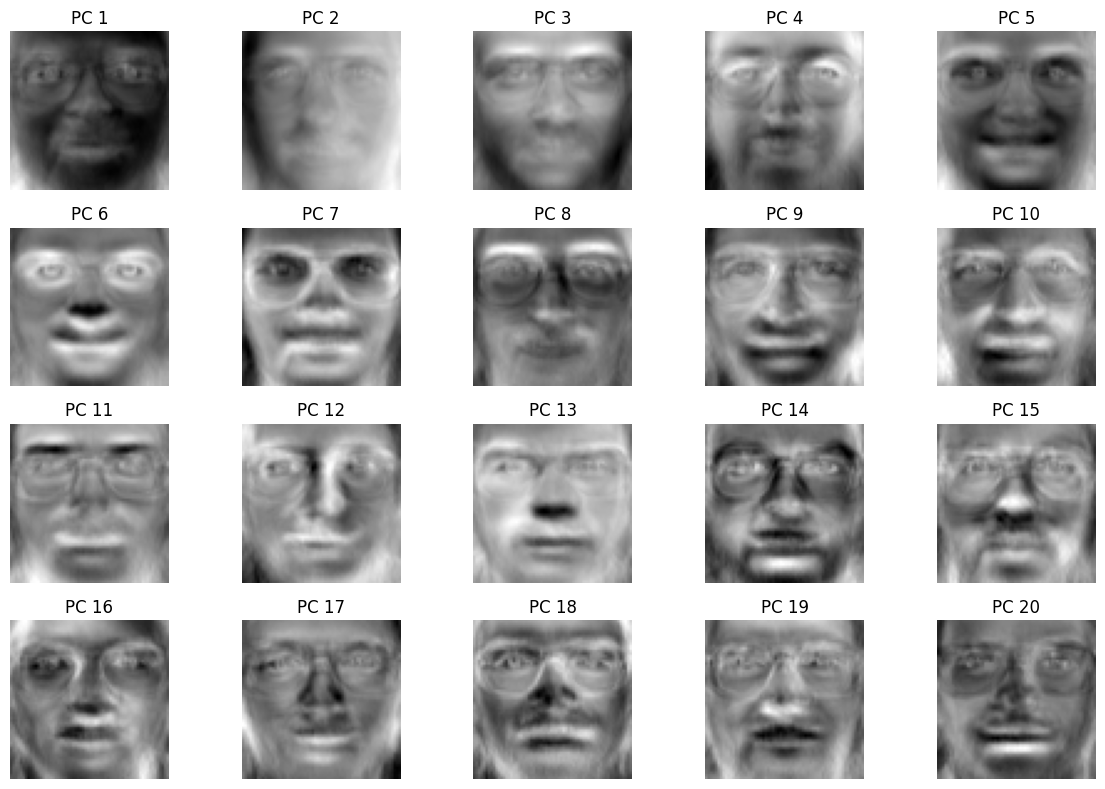

In [2]:

# ==================YOUR CODE HERE =================

plt.figure(figsize=(12, 8))
for i in range(num_components):
    plt.subplot(4, 5, i + 1)
    plt.imshow(principal_components[:, i].reshape(64, 64), cmap='gray')
    plt.title(f"PC {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ==================================================



Eigenfaces shape: (20, 64, 64)


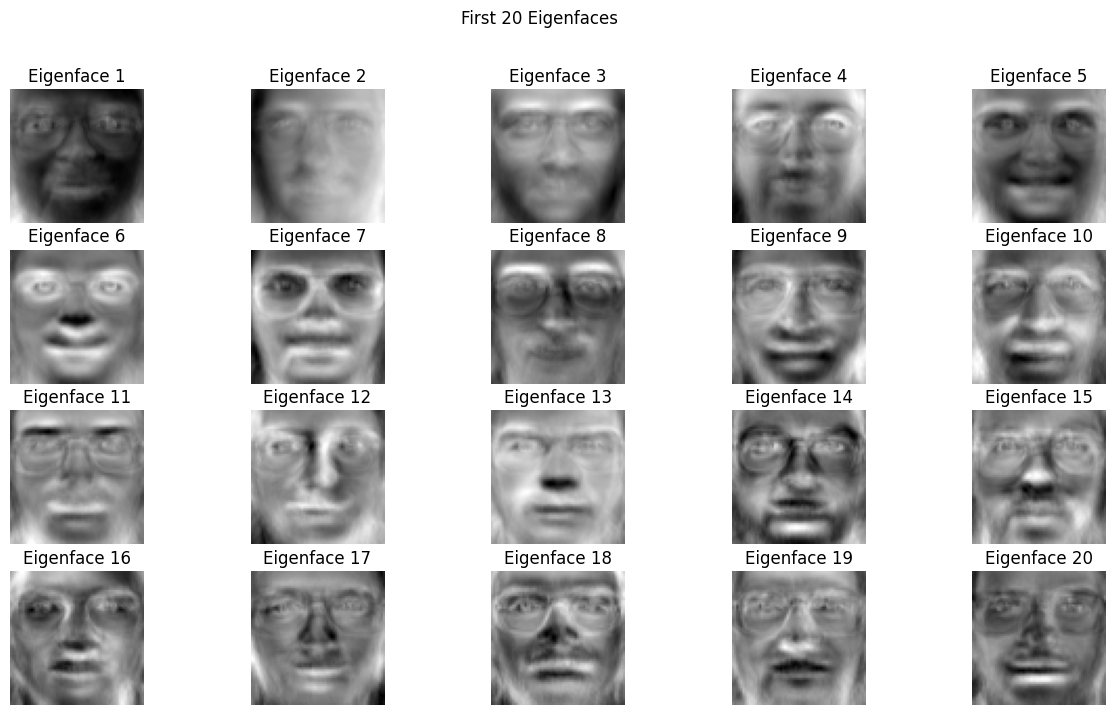

In [3]:


# Eigenfaces would be the principal components reshaped as images
eigenfaces = principal_components.T.reshape((-1, 64, 64))
print("Eigenfaces shape:", eigenfaces.shape)

# Visualize the first 20 eigenfaces
plt.figure(figsize=(15, 8))
for i, eigenface in enumerate(eigenfaces):
    plt.subplot(4, 5, i + 1)
    plt.imshow(eigenface.reshape(64, 64), cmap='gray')
    plt.title(f'Eigenface {i+1}')
    plt.axis('off')
plt.suptitle('First 20 Eigenfaces')
plt.show()

## Answer the following questions

1. When you rerun PCA with different choices of "number_of_components" do they return the same or different solutions? Why?
2. How would you interpret the eginfaces above?

When PCA is rerun with different values of number_of_components, the reduced outputs are different because each choice retains a different number of principal directions and therefore a different amount of information from the original data. However, the leading principal components are generally consistent, since they are determined by the same covariance structure of the dataset. This means that if more components are added, the earlier ones usually remain the same while additional lower-variance directions are included. The eigenfaces can be interpreted as the dominant patterns of variation across the face images rather than as real faces themselves. They capture broad features such as lighting differences, facial shape, and pose, and each face in the dataset can be reconstructed as a weighted combination of these eigenfaces. In this way, PCA provides a compact representation of the data while preserving the most important visual information.